In [ ]:
# Если запускаете ноутбук в чистом окружении, раскомментируйте:
%pip install pandas matplotlib psycopg2-binary

import os
import pandas as pd
import psycopg2
import matplotlib.pyplot as plt

PG_HOST = '62.60.228.129'
PG_PORT = 5432
PG_DB = 'analytics'
PG_USER = 'airflow'
PG_PASSWORD = 'airflow'

conn = psycopg2.connect(host=PG_HOST, port=PG_PORT, dbname=PG_DB, user=PG_USER, password=PG_PASSWORD)

Note: you may need to restart the kernel to use updated packages.


In [7]:
query = '''
select
  date_day,
  avg_temperature_c,
  min_temperature_c,
  max_temperature_c,
  avg_humidity,
  observations_count
from dbt_dm.dm_weather_daily
order by date_day
'''

df = pd.read_sql_query(query, conn)
df.head()

C:\Users\koshk\AppData\Local\Temp\ipykernel_11580\1658994188.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql_query(query, conn)


,date_day,avg_temperature_c,min_temperature_c,max_temperature_c,avg_humidity,observations_count
0,2025-12-17,9.516667,-7.5,27.9,53.666667,6
1,2025-12-18,8.757576,-9.9,28.3,62.757576,33


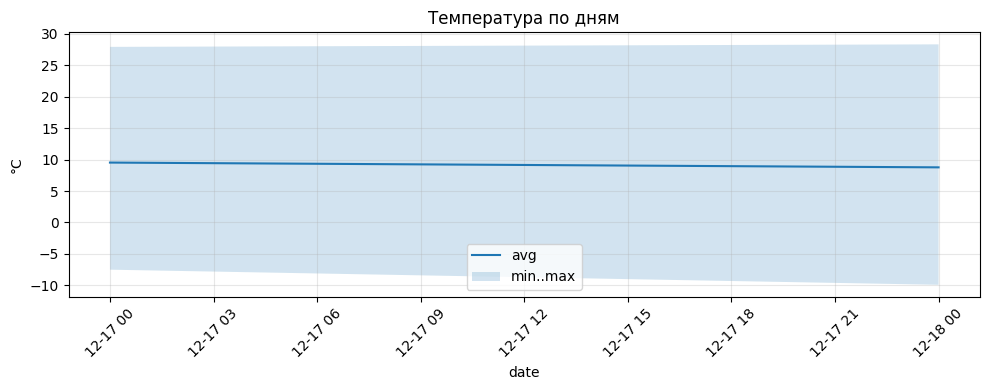

In [8]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(df['date_day'], df['avg_temperature_c'], label='avg')
ax.fill_between(df['date_day'], df['min_temperature_c'], df['max_temperature_c'], alpha=0.2, label='min..max')
ax.set_title('Температура по дням')
ax.set_xlabel('date')
ax.set_ylabel('°C')
ax.grid(True, alpha=0.3)
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

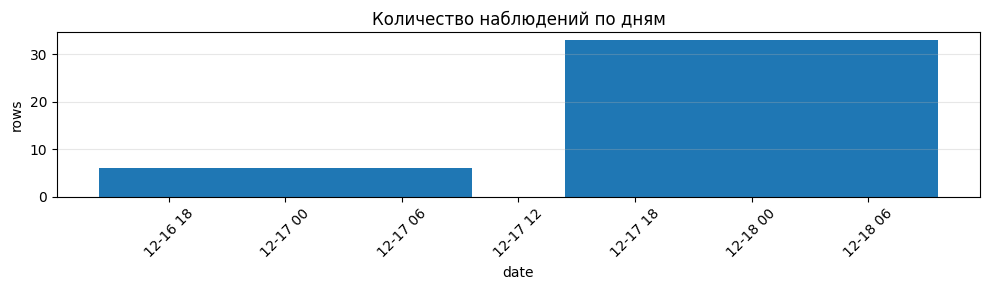

In [9]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(df['date_day'], df['observations_count'])
ax.set_title('Количество наблюдений по дням')
ax.set_xlabel('date')
ax.set_ylabel('rows')
ax.grid(True, axis='y', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Интерпретация

- График температуры показывает динамику средней температуры и дневной диапазон (min..max).
- `observations_count` помогает видеть, в какие дни данных меньше (возможные сбои генерации/EL). 